In [ ]:
# AI-Based Resume / Candidate Screening System

## Introduction

This project is a Machine Learning and NLP-based resume screening
system that automatically compares candidate resumes with a given
job description.

The system extracts relevant skills, calculates resume-to-job
similarity, ranks candidates, identifies missing skills, and provides
an easy-to-understand explanation of candidate suitability.

## Objectives

- Clean and preprocess resume text
- Extract relevant skills using NLP
- Parse job descriptions
- Calculate resume-to-role similarity
- Rank candidates based on job relevance
- Identify missing skills
- Provide explainable screening results

In [ ]:
import pandas as pd
import numpy as np

print("Python environment is ready!")

Python environment is ready!


In [ ]:
!pip install -q spacy nltk scikit-learn PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.1 MB/s eta 0:00:00


In [ ]:
import requests
import zipfile
import io
import pandas as pd

url = "https://www.kaggle.com/api/v1/datasets/download/snehaanbhawal/resume-dataset"

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    df = pd.read_csv(z.open("Resume/Resume.csv"))

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Dataset loaded successfully!
Shape: (2484, 4)
Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
print("Number of resumes:", len(df))

print("\nJob Categories:")
print(df["Category"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Number of resumes: 2484

Job Categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_resume"] = df["Resume_str"].apply(clean_text)

print("Cleaning completed!")
df[["Category", "clean_resume"]].head()

Cleaning completed!


,Category,clean_resume
0,HR,hr administrator marketing associate hr admini...
1,HR,hr specialist us hr operations summary versati...
2,HR,hr director summary over 20 years experience i...
3,HR,hr specialist summary dedicated driven and dyn...
4,HR,hr manager skill highlights hr skills hr depar...


In [ ]:
skills = [
    "python", "java", "c++", "sql", "machine learning",
    "deep learning", "artificial intelligence", "data science",
    "tensorflow", "pytorch", "scikit-learn", "pandas",
    "numpy", "nlp", "html", "css", "javascript",
    "react", "node.js", "git", "github", "excel",
    "power bi", "tableau", "aws", "azure", "docker"
]

def extract_skills(text):
    found_skills = []

    for skill in skills:
        if skill in text:
            found_skills.append(skill)

    return found_skills

df["extracted_skills"] = df["clean_resume"].apply(extract_skills)

print("Skill extraction completed!")
df[["Category", "extracted_skills"]].head(10)

Skill extraction completed!


,Category,extracted_skills
0,HR,[aws]
1,HR,[git]
2,HR,[excel]
3,HR,[excel]
4,HR,"[excel, aws]"
5,HR,[excel]
6,HR,[]
7,HR,[aws]
8,HR,"[excel, aws]"
9,HR,[aws]


In [ ]:
job_description = """
We are looking for a Data Scientist with strong skills in Python,
SQL, Machine Learning, Data Science, Pandas, NumPy and Scikit-learn.
Experience with NLP, TensorFlow and data analysis is preferred.
The candidate should have good problem-solving and analytical skills.
"""

print(job_description)


We are looking for a Data Scientist with strong skills in Python,
SQL, Machine Learning, Data Science, Pandas, NumPy and Scikit-learn.
Experience with NLP, TensorFlow and data analysis is preferred.
The candidate should have good problem-solving and analytical skills.



In [ ]:
clean_job_description = clean_text(job_description)

job_skills = extract_skills(clean_job_description)

print("Required skills:")
print(job_skills)

Required skills:
['python', 'sql', 'machine learning', 'data science', 'tensorflow', 'pandas', 'numpy', 'nlp']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

texts = [job_description] + df["Resume_str"].tolist()

vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(texts)

job_vector = tfidf_matrix[0]
resume_vectors = tfidf_matrix[1:]

similarity_scores = cosine_similarity(job_vector, resume_vectors).flatten()

df["similarity_score"] = similarity_scores * 100

print("Similarity scoring completed!")
df[["Category", "similarity_score"]].head(10)

Similarity scoring completed!


,Category,similarity_score
0,HR,2.236201
1,HR,0.136514
2,HR,0.311168
3,HR,0.589444
4,HR,0.760356
5,HR,0.610956
6,HR,0.362659
7,HR,1.822142
8,HR,3.063035
9,HR,1.164305


In [ ]:
df["rank"] = df["similarity_score"].rank(
    ascending=False,
    method="first"
).astype(int)

ranked_candidates = df.sort_values(
    "similarity_score",
    ascending=False
)

print("Top 10 candidates:")
display(
    ranked_candidates[
        ["ID", "Category", "similarity_score", "extracted_skills", "rank"]
    ].head(10)
)

Top 10 candidates:


,ID,Category,similarity_score,extracted_skills,rank
926,62994611,AGRICULTURE,20.497632,"[python, java, sql, tensorflow, pandas, html, ...",1
1339,18448085,AUTOMOBILE,19.559561,"[python, sql, data science, pandas, numpy, exc...",2
1762,12011623,ENGINEERING,16.673604,"[python, sql, machine learning, pandas, html, ...",3
1218,21156767,CONSULTANT,15.811973,"[python, java, sql, machine learning, data sci...",4
1091,24610685,SALES,11.947767,"[java, sql, html, css, javascript, excel, tabl...",5
1142,30863060,CONSULTANT,11.295136,"[java, sql, html, javascript, excel, tableau]",6
331,18067556,INFORMATION-TECHNOLOGY,11.026991,"[python, sql, html, css, excel, tableau, aws, ...",7
1303,42156237,DIGITAL-MEDIA,10.717156,"[python, java, sql, html, javascript, git, exc...",8
2153,34953092,BANKING,9.924041,"[python, sql, machine learning]",9
929,11813872,AGRICULTURE,9.210226,"[python, java, sql, data science, pandas, aws]",10


In [ ]:
def find_missing_skills(candidate_skills, required_skills):
    return [skill for skill in required_skills if skill not in candidate_skills]

ranked_candidates["missing_skills"] = ranked_candidates[
    "extracted_skills"
].apply(
    lambda x: find_missing_skills(x, job_skills)
)

print("Skill gap analysis completed!")

display(
    ranked_candidates[
        ["ID", "Category", "similarity_score",
         "extracted_skills", "missing_skills", "rank"]
    ].head(10)
)

Skill gap analysis completed!


,ID,Category,similarity_score,extracted_skills,missing_skills,rank
926,62994611,AGRICULTURE,20.497632,"[python, java, sql, tensorflow, pandas, html, ...","[machine learning, data science, numpy, nlp]",1
1339,18448085,AUTOMOBILE,19.559561,"[python, sql, data science, pandas, numpy, exc...","[machine learning, tensorflow, nlp]",2
1762,12011623,ENGINEERING,16.673604,"[python, sql, machine learning, pandas, html, ...","[data science, tensorflow, numpy, nlp]",3
1218,21156767,CONSULTANT,15.811973,"[python, java, sql, machine learning, data sci...","[tensorflow, pandas, numpy, nlp]",4
1091,24610685,SALES,11.947767,"[java, sql, html, css, javascript, excel, tabl...","[python, machine learning, data science, tenso...",5
1142,30863060,CONSULTANT,11.295136,"[java, sql, html, javascript, excel, tableau]","[python, machine learning, data science, tenso...",6
331,18067556,INFORMATION-TECHNOLOGY,11.026991,"[python, sql, html, css, excel, tableau, aws, ...","[machine learning, data science, tensorflow, p...",7
1303,42156237,DIGITAL-MEDIA,10.717156,"[python, java, sql, html, javascript, git, exc...","[machine learning, data science, tensorflow, p...",8
2153,34953092,BANKING,9.924041,"[python, sql, machine learning]","[data science, tensorflow, pandas, numpy, nlp]",9
929,11813872,AGRICULTURE,9.210226,"[python, java, sql, data science, pandas, aws]","[machine learning, tensorflow, numpy, nlp]",10


In [ ]:
top_candidates = ranked_candidates.head(10).copy()

top_candidates["match_score"] = top_candidates["similarity_score"].round(2)

final_report = top_candidates[
    ["ID", "Category", "match_score",
     "extracted_skills", "missing_skills", "rank"]
]

display(final_report)

,ID,Category,match_score,extracted_skills,missing_skills,rank
926,62994611,AGRICULTURE,20.50,"[python, java, sql, tensorflow, pandas, html, ...","[machine learning, data science, numpy, nlp]",1
1339,18448085,AUTOMOBILE,19.56,"[python, sql, data science, pandas, numpy, exc...","[machine learning, tensorflow, nlp]",2
1762,12011623,ENGINEERING,16.67,"[python, sql, machine learning, pandas, html, ...","[data science, tensorflow, numpy, nlp]",3
1218,21156767,CONSULTANT,15.81,"[python, java, sql, machine learning, data sci...","[tensorflow, pandas, numpy, nlp]",4
1091,24610685,SALES,11.95,"[java, sql, html, css, javascript, excel, tabl...","[python, machine learning, data science, tenso...",5
1142,30863060,CONSULTANT,11.30,"[java, sql, html, javascript, excel, tableau]","[python, machine learning, data science, tenso...",6
331,18067556,INFORMATION-TECHNOLOGY,11.03,"[python, sql, html, css, excel, tableau, aws, ...","[machine learning, data science, tensorflow, p...",7
1303,42156237,DIGITAL-MEDIA,10.72,"[python, java, sql, html, javascript, git, exc...","[machine learning, data science, tensorflow, p...",8
2153,34953092,BANKING,9.92,"[python, sql, machine learning]","[data science, tensorflow, pandas, numpy, nlp]",9
929,11813872,AGRICULTURE,9.21,"[python, java, sql, data science, pandas, aws]","[machine learning, tensorflow, numpy, nlp]",10


In [ ]:
def explain_candidate(row):
    matched = row["extracted_skills"]
    missing = row["missing_skills"]
    score = row["match_score"]

    explanation = f"Candidate {row['ID']} has a match score of {score}%. "

    if matched:
        explanation += (
            "Matched skills: " + ", ".join(matched) + ". "
        )
    else:
        explanation += "No skills from the required skill list were detected. "

    if missing:
        explanation += (
            "Missing skills: " + ", ".join(missing) + "."
        )
    else:
        explanation += "No required skills are missing."

    return explanation


top_candidate = final_report.iloc[0]

print(explain_candidate(top_candidate))

Candidate 62994611 has a match score of 20.5%. Matched skills: python, java, sql, tensorflow, pandas, html, css, javascript, react, excel, tableau. Missing skills: machine learning, data science, numpy, nlp.


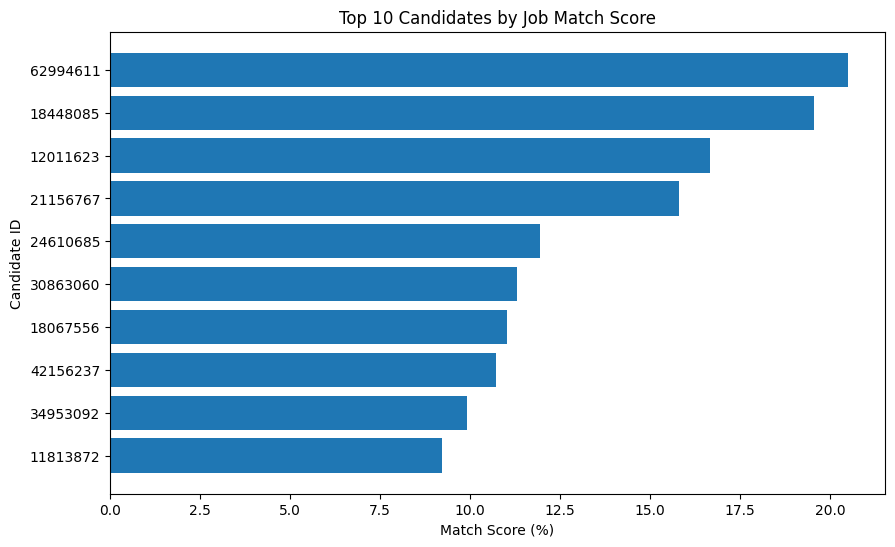

In [ ]:
import matplotlib.pyplot as plt

top_10 = ranked_candidates.head(10).copy()

plt.figure(figsize=(10, 6))
plt.barh(
    top_10["ID"].astype(str),
    top_10["similarity_score"]
)

plt.xlabel("Match Score (%)")
plt.ylabel("Candidate ID")
plt.title("Top 10 Candidates by Job Match Score")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
print("Top 5 Candidates")
print("=" * 50)

for _, row in ranked_candidates.head(5).iterrows():
    print(f"Rank: {row['rank']}")
    print(f"Candidate ID: {row['ID']}")
    print(f"Category: {row['Category']}")
    print(f"Match Score: {row['similarity_score']:.2f}%")
    print(f"Matched Skills: {', '.join(row['extracted_skills']) if row['extracted_skills'] else 'None'}")
    print(f"Missing Skills: {', '.join(row['missing_skills']) if row['missing_skills'] else 'None'}")
    print("-" * 50)

Top 5 Candidates
Rank: 1
Candidate ID: 62994611
Category: AGRICULTURE
Match Score: 20.50%
Matched Skills: python, java, sql, tensorflow, pandas, html, css, javascript, react, excel, tableau
Missing Skills: machine learning, data science, numpy, nlp
--------------------------------------------------
Rank: 2
Candidate ID: 18448085
Category: AUTOMOBILE
Match Score: 19.56%
Matched Skills: python, sql, data science, pandas, numpy, excel, tableau
Missing Skills: machine learning, tensorflow, nlp
--------------------------------------------------
Rank: 3
Candidate ID: 12011623
Category: ENGINEERING
Match Score: 16.67%
Matched Skills: python, sql, machine learning, pandas, html, excel, tableau
Missing Skills: data science, tensorflow, numpy, nlp
--------------------------------------------------
Rank: 4
Candidate ID: 21156767
Category: CONSULTANT
Match Score: 15.81%
Matched Skills: python, java, sql, machine learning, data science, javascript, azure
Missing Skills: tensorflow, pandas, numpy, n

In [ ]:
final_report.to_csv(
    "resume_screening_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
